In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split

In [6]:
# Assuming you have a CSV file for Adani Ports stock data
df = pd.read_csv('ADANIPORTS.NS (1).csv')

# Display the first few rows
df.head()


,Date,Open,High,Low,Close,Adj Close,Volume
0,2019-08-22,348.799988,348.799988,340.799988,345.049988,332.896515,2171160
1,2019-08-23,346.399994,354.149994,339.649994,349.350006,337.045105,2246560
2,2019-08-26,366.000000,375.000000,349.350006,368.200012,355.231140,4974219
3,2019-08-27,370.299988,374.250000,367.299988,372.049988,358.945526,3040184
4,2019-08-28,373.100006,374.250000,364.049988,365.950012,353.060455,2186454


In [7]:
df.isna()

,Date,Open,High,Low,Close,Adj Close,Volume
0,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...
1231,False,False,False,False,False,False,False
1232,False,False,False,False,False,False,False
1233,False,False,False,False,False,False,False
1234,False,False,False,False,False,False,False


In [8]:
df.dtypes

Date          object
Open         float64
High         float64
Low          float64
Close        float64
Adj Close    float64
Volume         int64
dtype: object

In [9]:
# Display basic information and summary statistics
df.shape  # Get the number of rows and columns


(1236, 7)

In [10]:
df.describe()

,Open,High,Low,Close,Adj Close,Volume
count,1236.000000,1236.000000,1236.000000,1236.000000,1236.000000,1.236000e+03
mean,721.776498,732.289484,709.372046,720.448665,710.708902,7.436331e+06
std,310.355453,313.684996,305.694542,309.470708,311.337635,9.351874e+06
min,216.000000,235.800003,203.000000,207.800003,202.696472,1.101140e+05
25%,410.974998,417.799996,404.749992,413.199997,399.345627,2.987367e+06
50%,731.000000,740.975006,720.625000,729.875000,716.823700,4.690138e+06
75%,821.000000,830.537506,807.125000,819.349991,810.760025,8.011984e+06
max,1580.949951,1621.400024,1568.500000,1590.150024,1590.150024,1.155175e+08


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1236 entries, 0 to 1235
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       1236 non-null   object 
 1   Open       1236 non-null   float64
 2   High       1236 non-null   float64
 3   Low        1236 non-null   float64
 4   Close      1236 non-null   float64
 5   Adj Close  1236 non-null   float64
 6   Volume     1236 non-null   int64  
dtypes: float64(5), int64(1), object(1)
memory usage: 67.7+ KB


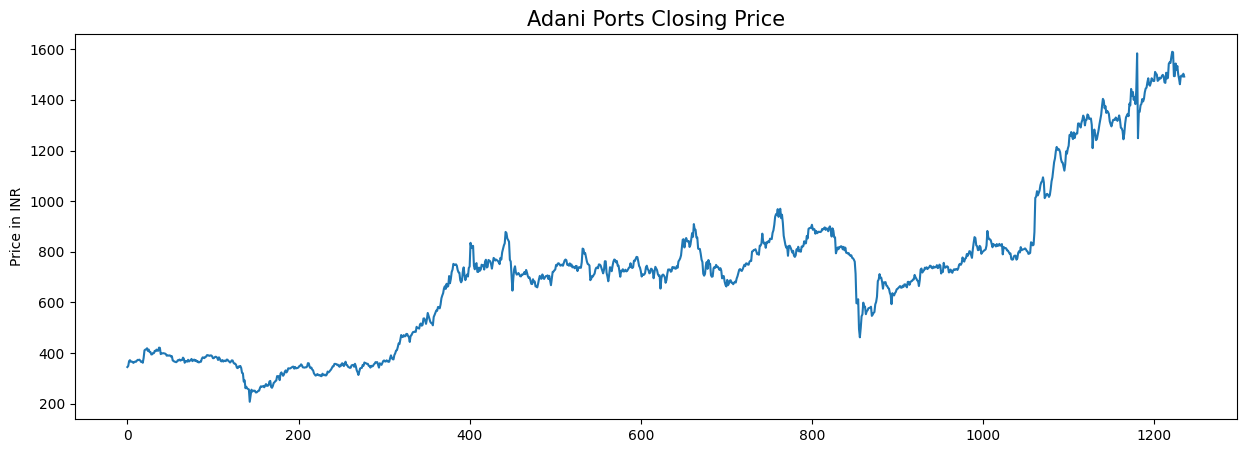

In [12]:
# Plotting the Adani Ports Closing Price
plt.figure(figsize=(15,5))
plt.plot(df['Close'])
plt.title('Adani Ports Closing Price', fontsize=15)
plt.ylabel('Price in INR')
plt.show()


In [13]:
df[df['Close'] == df['Adj Close']].shape

(47, 7)

In [14]:
df = df.drop(['Adj Close'], axis=1)


In [15]:
%pip install seaborn


Note: you may need to restart the kernel to use updated packages.Requirement already satisfied: seaborn in c:\users\maha\appdata\local\programs\python\python312\lib\site-packages (0.13.2)




[notice] A new release of pip is available: 24.0 -> 24.3.1
[notice] To update, run: python.exe -m pip install --upgrade pip


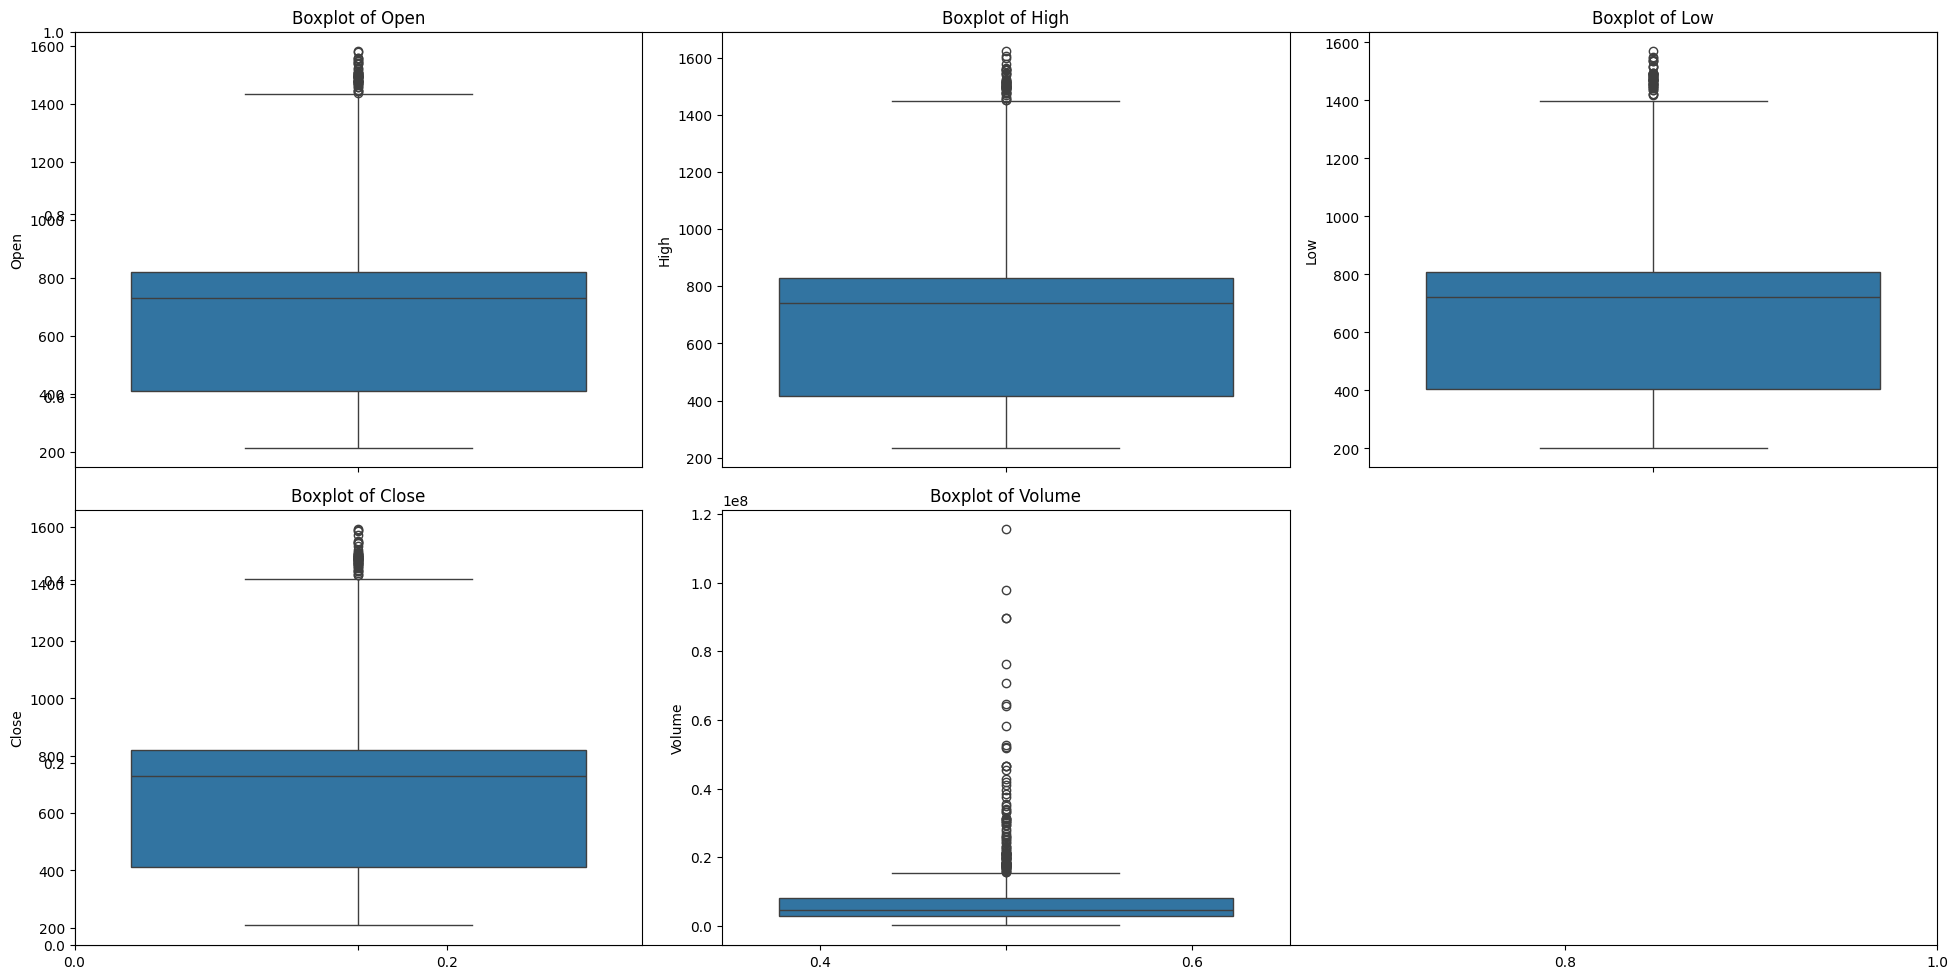

In [16]:
import matplotlib.pyplot as plt
import seaborn as sb

# Define the list of features you want to visualize
features = ['Open', 'High', 'Low', 'Close', 'Volume']

# Create a subplot to fit the box plots for each feature
plt.subplots(figsize=(20, 10))

# Iterate over the features and create a box plot for each
for i, col in enumerate(features):
    plt.subplot(2, 3, i+1)  # Create a 2x3 grid of subplots
    sb.boxplot(df[col])  # Create the box plot for each feature
    plt.title(f'Boxplot of {col}')  # Set the title for each box plot

# Display the plots
plt.tight_layout()  # Adjust spacing between subplots
plt.show()


In [17]:
# Select only numeric columns
numeric_columns = df.select_dtypes(include=[np.number])

# Calculate the IQR for each numeric column
Q1 = numeric_columns.quantile(0.25)
Q3 = numeric_columns.quantile(0.75)
IQR = Q3 - Q1

# Define outlier condition
outliers = ((numeric_columns < (Q1 - 1.5 * IQR)) | (numeric_columns > (Q3 + 1.5 * IQR)))

# Find outliers for each numeric feature
outliers_summary = outliers.sum()

# Display outliers count for each column
print("Outliers in each numeric column:\n", outliers_summary)


Outliers in each numeric column:
 Open       50
High       50
Low        48
Close      51
Volume    110
dtype: int64


In [18]:
# Select only numeric columns
numeric_cols = df.select_dtypes(include=[np.number]).columns

# Calculate the IQR for each numeric column
Q1 = df[numeric_cols].quantile(0.25)
Q3 = df[numeric_cols].quantile(0.75)
IQR = Q3 - Q1

# Define a filter to remove outliers
filter_outliers = ~((df[numeric_cols] < (Q1 - 1.5 * IQR)) | (df[numeric_cols] > (Q3 + 1.5 * IQR))).any(axis=1)

# Apply the filter to remove outliers
df_cleaned = df[filter_outliers]

# Check the shape of the original and cleaned dataset
print(f"Original data shape: {df.shape}")
print(f"Cleaned data shape: {df_cleaned.shape}")


Original data shape: (1236, 6)
Cleaned data shape: (1076, 6)


In [19]:
# Apply the filter to remove outliers
data = df[filter_outliers]

# Check the shape of the original and cleaned dataset
print(f"Original data shape: {df.shape}")
print(f"Cleaned data shape: {data.shape}")


Original data shape: (1236, 6)
Cleaned data shape: (1076, 6)


In [20]:
data.head()

,Date,Open,High,Low,Close,Volume
0,2019-08-22,348.799988,348.799988,340.799988,345.049988,2171160
1,2019-08-23,346.399994,354.149994,339.649994,349.350006,2246560
2,2019-08-26,366.000000,375.000000,349.350006,368.200012,4974219
3,2019-08-27,370.299988,374.250000,367.299988,372.049988,3040184
4,2019-08-28,373.100006,374.250000,364.049988,365.950012,2186454


In [21]:
# Ensure the 'Date' column is in datetime format (if not already)
data['Date'] = pd.to_datetime(data['Date'])

# Extract Day, Month, and Year from the 'Date' column
data['Day'] = data['Date'].dt.day
data['Month'] = data['Date'].dt.month
data['Year'] = data['Date'].dt.year

# Display the updated data
print(data.head())


        Date        Open        High         Low       Close   Volume  Day  \
0 2019-08-22  348.799988  348.799988  340.799988  345.049988  2171160   22   
1 2019-08-23  346.399994  354.149994  339.649994  349.350006  2246560   23   
2 2019-08-26  366.000000  375.000000  349.350006  368.200012  4974219   26   
3 2019-08-27  370.299988  374.250000  367.299988  372.049988  3040184   27   
4 2019-08-28  373.100006  374.250000  364.049988  365.950012  2186454   28   

   Month  Year  
0      8  2019  
1      8  2019  
2      8  2019  
3      8  2019  
4      8  2019  


C:\Users\maha\AppData\Local\Temp\ipykernel_11136\3146206698.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['Date'] = pd.to_datetime(data['Date'])
C:\Users\maha\AppData\Local\Temp\ipykernel_11136\3146206698.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['Day'] = data['Date'].dt.day
C:\Users\maha\AppData\Local\Temp\ipykernel_11136\3146206698.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value inst

In [22]:
# Ensure the 'Date' column is in datetime format (if not already)
data.loc[:, 'Date'] = pd.to_datetime(data['Date'])

# Extract Day, Month, and Year from the 'Date' column
data.loc[:, 'Day'] = data['Date'].dt.day
data.loc[:, 'Month'] = data['Date'].dt.month
data.loc[:, 'Year'] = data['Date'].dt.year

# Display the updated data
print(data.head())


        Date        Open        High         Low       Close   Volume  Day  \
0 2019-08-22  348.799988  348.799988  340.799988  345.049988  2171160   22   
1 2019-08-23  346.399994  354.149994  339.649994  349.350006  2246560   23   
2 2019-08-26  366.000000  375.000000  349.350006  368.200012  4974219   26   
3 2019-08-27  370.299988  374.250000  367.299988  372.049988  3040184   27   
4 2019-08-28  373.100006  374.250000  364.049988  365.950012  2186454   28   

   Month  Year  
0      8  2019  
1      8  2019  
2      8  2019  
3      8  2019  
4      8  2019  


In [23]:
# Drop the 'Date' column
data = data.drop(columns=['Date'])

# Display the updated data
print(data.head())


         Open        High         Low       Close   Volume  Day  Month  Year
0  348.799988  348.799988  340.799988  345.049988  2171160   22      8  2019
1  346.399994  354.149994  339.649994  349.350006  2246560   23      8  2019
2  366.000000  375.000000  349.350006  368.200012  4974219   26      8  2019
3  370.299988  374.250000  367.299988  372.049988  3040184   27      8  2019
4  373.100006  374.250000  364.049988  365.950012  2186454   28      8  2019


            Open      High       Low     Close    Volume       Day     Month  \
Open    1.000000  0.999585  0.999404  0.998930  0.062332 -0.034699 -0.127302   
High    0.999585  1.000000  0.999401  0.999527  0.072278 -0.035370 -0.129590   
Low     0.999404  0.999401  1.000000  0.999595  0.055723 -0.036231 -0.126317   
Close   0.998930  0.999527  0.999595  1.000000  0.064265 -0.037954 -0.129148   
Volume  0.062332  0.072278  0.055723  0.064265  1.000000 -0.004095 -0.056373   
Day    -0.034699 -0.035370 -0.036231 -0.037954 -0.004095  1.000000  0.017765   
Month  -0.127302 -0.129590 -0.126317 -0.129148 -0.056373  0.017765  1.000000   
Year    0.868355  0.868571  0.868968  0.868891  0.044761 -0.039578 -0.285589   

            Year  
Open    0.868355  
High    0.868571  
Low     0.868968  
Close   0.868891  
Volume  0.044761  
Day    -0.039578  
Month  -0.285589  
Year    1.000000  


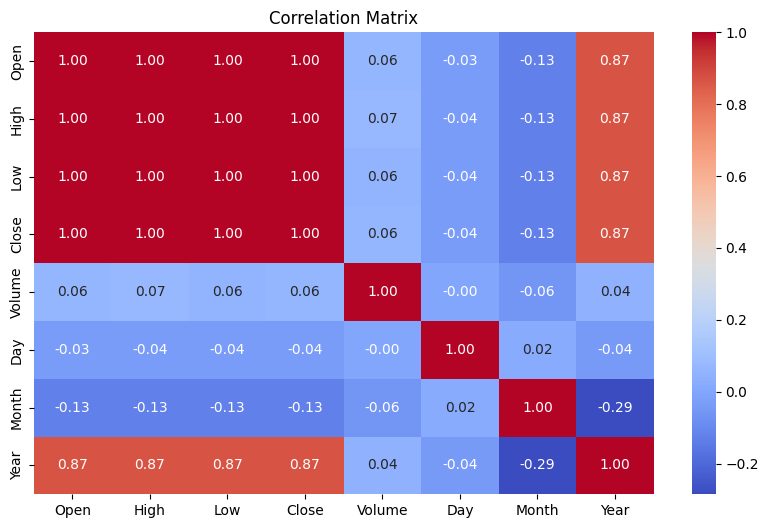

In [24]:
# Calculate correlation between numeric columns
correlation_matrix = data.corr()

# Display the correlation matrix
print(correlation_matrix)

# Optional: Visualize the correlation matrix using a heatmap
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', cbar=True)
plt.title('Correlation Matrix')
plt.show()


In [25]:
data['Price_Range'] = data['High'] - data['Low']
data['Daily_Change'] = data['Close'] - data['Open']
data['Daily_Change'] = data['Close'] - data['Open']


In [26]:
data = data.drop(columns=['Open', 'High', 'Low'])


In [27]:
data.head()

,Close,Volume,Day,Month,Year,Price_Range,Daily_Change
0,345.049988,2171160,22,8,2019,8.000000,-3.750000
1,349.350006,2246560,23,8,2019,14.500000,2.950012
2,368.200012,4974219,26,8,2019,25.649994,2.200012
3,372.049988,3040184,27,8,2019,6.950012,1.750000
4,365.950012,2186454,28,8,2019,10.200012,-7.149994


In [28]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
data['Volume_Normalized'] = scaler.fit_transform(data[['Volume']])


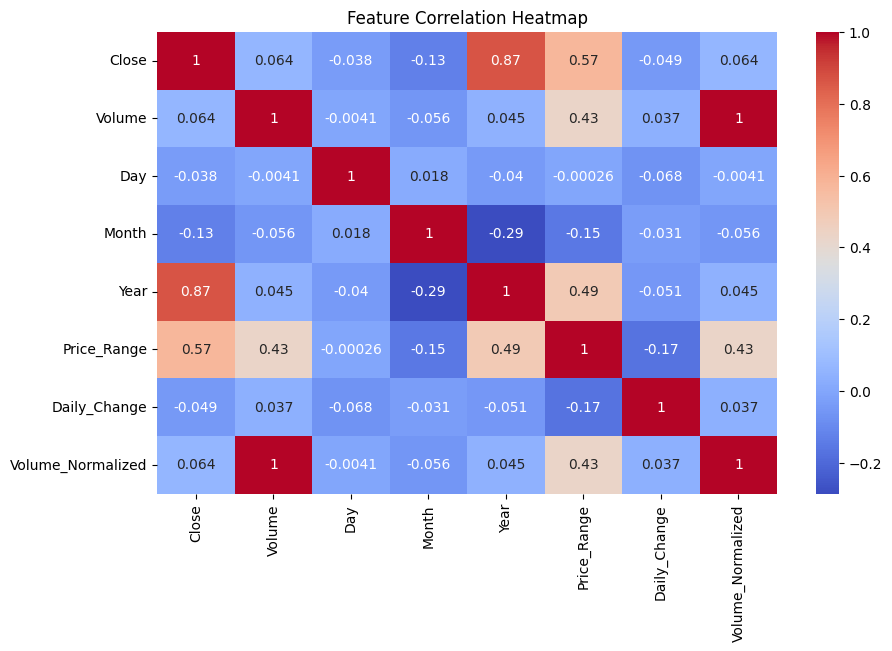

In [29]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.heatmap(data.corr(), annot=True, cmap='coolwarm')
plt.title("Feature Correlation Heatmap")
plt.show()


In [30]:
data['MA_5'] = data['Close'].rolling(window=5).mean()
data['MA_10'] = data['Close'].rolling(window=10).mean()

# Adding Relative Volume
data['Relative_Volume'] = data['Volume'] / data['Volume'].rolling(window=5).mean()

# Adding Percent Change
data['Percent_Change'] = data['Close'].pct_change() * 100

# Adding Quarter
data['Quarter'] = data['Month'].apply(lambda x: (x - 1) // 3 + 1)

# Adding Lag Features
data['Close_Lag1'] = data['Close'].shift(1)
data['Price_Range_Lag1'] = data['Price_Range'].shift(1)


# Display the enhanced dataset
print(data.head())

        Close   Volume  Day  Month  Year  Price_Range  Daily_Change  \
0  345.049988  2171160   22      8  2019     8.000000     -3.750000   
1  349.350006  2246560   23      8  2019    14.500000      2.950012   
2  368.200012  4974219   26      8  2019    25.649994      2.200012   
3  372.049988  3040184   27      8  2019     6.950012      1.750000   
4  365.950012  2186454   28      8  2019    10.200012     -7.149994   

   Volume_Normalized        MA_5  MA_10  Relative_Volume  Percent_Change  \
0           0.133793         NaN    NaN              NaN             NaN   
1           0.138687         NaN    NaN              NaN        1.246201   
2           0.315753         NaN    NaN              NaN        5.395737   
3           0.190206         NaN    NaN              NaN        1.045621   
4           0.134786  360.120001    NaN         0.747834       -1.639558   

   Quarter  Close_Lag1  Price_Range_Lag1  
0        3         NaN               NaN  
1        3  345.049988        

In [31]:
data.ffill(inplace=True)
data.bfill(inplace=True)

In [32]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
data[['Close', 'Volume', 'Price_Range', 'Daily_Change']] = scaler.fit_transform(data[['Close', 'Volume', 'Price_Range', 'Daily_Change']])

In [33]:
corr = data.corr()
print(corr['Close'])

Close                1.000000
Volume               0.064265
Day                 -0.037954
Month               -0.129148
Year                 0.868891
Price_Range          0.573714
Daily_Change        -0.049102
Volume_Normalized    0.064265
MA_5                 0.997617
MA_10                0.994128
Relative_Volume     -0.007067
Percent_Change       0.039017
Quarter             -0.134851
Close_Lag1           0.998070
Price_Range_Lag1     0.579006
Name: Close, dtype: float64


In [34]:
# Remove the highly correlated features: 'MA_5', 'MA_10', 'Close_Lag1'
data_cleaned = data.drop(columns=['MA_5', 'MA_10', 'Close_Lag1'])

# Verify the changes
print(data_cleaned.head())


      Close    Volume  Day  Month  Year  Price_Range  Daily_Change  \
0  0.114166  0.133793   22      8  2019     0.043998      0.603348   
1  0.117742  0.138687   23      8  2019     0.099530      0.646491   
2  0.133422  0.315753   26      8  2019     0.194788      0.641661   
3  0.136625  0.190206   27      8  2019     0.035028      0.638764   
4  0.131550  0.134786   28      8  2019     0.062794      0.581455   

   Volume_Normalized  Relative_Volume  Percent_Change  Quarter  \
0           0.133793         0.747834        1.246201        3   
1           0.138687         0.747834        1.246201        3   
2           0.315753         0.747834        5.395737        3   
3           0.190206         0.747834        1.045621        3   
4           0.134786         0.747834       -1.639558        3   

   Price_Range_Lag1  
0          8.000000  
1          8.000000  
2         14.500000  
3         25.649994  
4          6.950012  


In [35]:
# Drop the 'Close' column from the features (X) and assign it to y (target)
X = data_cleaned.drop(columns=['Close'])

# The target variable is 'Close'
y = data_cleaned['Close']

# Now X contains the features and y contains the target


In [36]:
from sklearn.model_selection import train_test_split
# Split the data into training and testing sets (80% for training, 20% for testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


# Check the size of the resulting sets
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)



(860, 11) (216, 11) (860,) (216,)


In [37]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, AdaBoostRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Initialize the models
models = {
    "Linear Regression": LinearRegression(),
    "Random Forest Regressor": RandomForestRegressor(),
    "Decision Tree Regressor": DecisionTreeRegressor(),
    "Support Vector Regressor": SVR(),
    "K-Nearest Neighbors Regressor": KNeighborsRegressor(),
    "Ridge Regression": Ridge(),
    "Lasso Regression": Lasso(),
    "ElasticNet Regression": ElasticNet(),
    "Gradient Boosting Regressor": GradientBoostingRegressor(),
    "AdaBoost Regressor": AdaBoostRegressor()
}

# Dictionary to store the evaluation results
model_results = {}

# Train and evaluate each model
for name, model in models.items():
    # Train the model
    model.fit(X_train, y_train)
    
    # Predict on the test set
    y_pred = model.predict(X_test)
    
    # Evaluate the model
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    
    # Store the results
    model_results[name] = {"MAE": mae, "MSE": mse, "R²": r2}

# Display the results
for name, results in model_results.items():
    print(f"{name} -> MAE: {results['MAE']}, MSE: {results['MSE']}, R²: {results['R²']}")

# Find the best model (based on R² score)
best_model_name = max(model_results, key=lambda x: model_results[x]['R²'])
best_model = models[best_model_name]

print(f"\nBest Model: {best_model_name} with R²: {model_results[best_model_name]['R²']}")


Linear Regression -> MAE: 0.0822888281307514, MSE: 0.010487514547219752, R²: 0.8078717946430605
Random Forest Regressor -> MAE: 0.017211624854407078, MSE: 0.0006263555308074612, R²: 0.988525349499388
Decision Tree Regressor -> MAE: 0.020287458810646045, MSE: 0.0010941598352454142, R²: 0.9799553111871415
Support Vector Regressor -> MAE: 0.17802853480495504, MSE: 0.05043512646728358, R²: 0.07604320437597833
K-Nearest Neighbors Regressor -> MAE: 0.11474129930525657, MSE: 0.02855672827139713, R²: 0.47684907334848003
Ridge Regression -> MAE: 0.08222183099297341, MSE: 0.010475588231343466, R²: 0.8080902812688013
Lasso Regression -> MAE: 0.16366140595409165, MSE: 0.044591206535929524, R²: 0.18310211176584723
ElasticNet Regression -> MAE: 0.15782453630087684, MSE: 0.039539336825648114, R²: 0.27565089029323997
Gradient Boosting Regressor -> MAE: 0.026867382978485153, MSE: 0.0012610177569948742, R²: 0.976898522764015
AdaBoost Regressor -> MAE: 0.03449403380812669, MSE: 0.0018765286505850712, R²:

In [38]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Initialize and fit the model
rf_model = RandomForestRegressor()
rf_model.fit(X_train, y_train)

# Make predictions
y_pred = rf_model.predict(X_test)

# Evaluate the model
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"MAE: {mae}")
print(f"MSE: {mse}")
print(f"R²: {r2}")


MAE: 0.017471289333026
MSE: 0.0006166502035121834
R²: 0.9887031482625981


In [39]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Initialize and fit the model
best_rf_model = RandomForestRegressor()
best_rf_model.fit(X_train, y_train)

# Make predictions
y_pred = rf_model.predict(X_test)

# Evaluate the model
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"MAE: {mae}")
print(f"MSE: {mse}")
print(f"R²: {r2}")


MAE: 0.017471289333026
MSE: 0.0006166502035121834
R²: 0.9887031482625981


In [40]:
from sklearn.model_selection import GridSearchCV

# Define hyperparameters to tune
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, 30],
    'min_samples_split': [2, 5, 10]
}

grid_search = GridSearchCV(estimator=best_rf_model, param_grid=param_grid, cv=5, n_jobs=-1, verbose=2)
grid_search.fit(X_train, y_train)

print(f"Best Hyperparameters: {grid_search.best_params_}")


Fitting 5 folds for each of 27 candidates, totalling 135 fits
Best Hyperparameters: {'max_depth': 30, 'min_samples_split': 2, 'n_estimators': 200}


In [41]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Get predictions on the test set
y_pred = best_rf_model.predict(X_test)

# Calculate performance metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"MAE: {mae}")
print(f"MSE: {mse}")
print(f"R²: {r2}")


MAE: 0.01780818916068883
MSE: 0.0006506146733475111
R²: 0.988080929088934


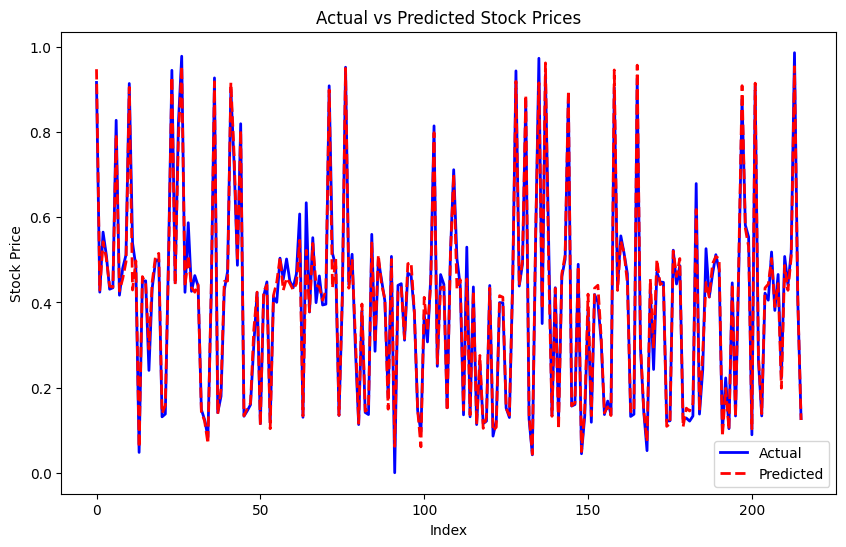

In [42]:
import matplotlib.pyplot as plt

# Plotting Actual vs Predicted values
plt.figure(figsize=(10, 6))
plt.plot(y_test.values, label='Actual', color='blue', linewidth=2)
plt.plot(y_pred, label='Predicted', color='red', linestyle='dashed', linewidth=2)
plt.title('Actual vs Predicted Stock Prices')
plt.xlabel('Index')
plt.ylabel('Stock Price')
plt.legend()
plt.show()


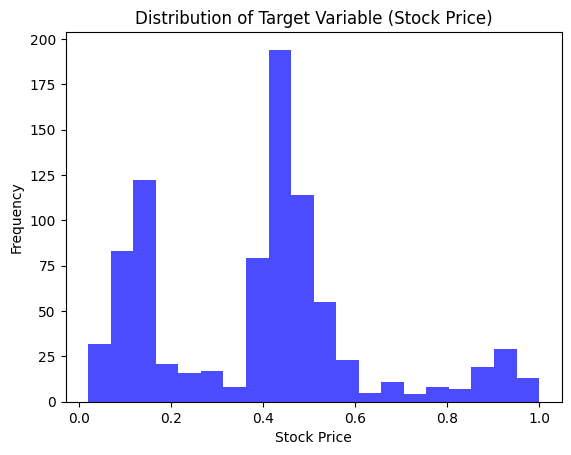

In [43]:
import matplotlib.pyplot as plt

# Plot distribution of the target variable
plt.hist(y_train, bins=20, color='blue', alpha=0.7)
plt.title('Distribution of Target Variable (Stock Price)')
plt.xlabel('Stock Price')
plt.ylabel('Frequency')
plt.show()


              Feature  Importance
3                Year    0.937393
2               Month    0.045898
1                 Day    0.002631
0              Volume    0.002399
6   Volume_Normalized    0.002095
10   Price_Range_Lag1    0.002035
8      Percent_Change    0.001884
7     Relative_Volume    0.001529
9             Quarter    0.001462
4         Price_Range    0.001418
5        Daily_Change    0.001255


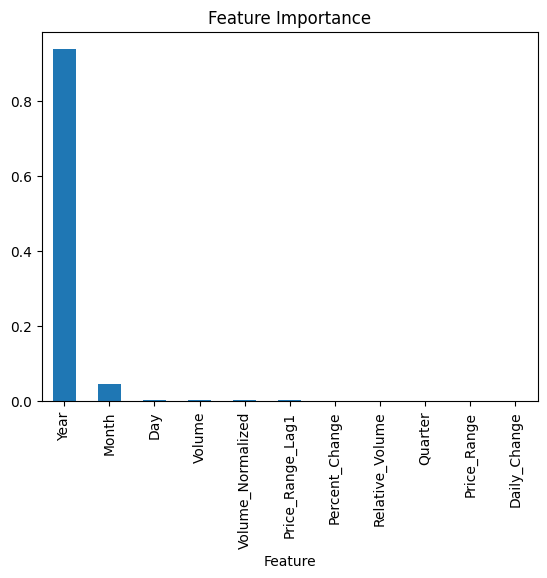

In [44]:
import pandas as pd

# Get feature importance
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

print(feature_importance)

# Plot feature importance
feature_importance.plot(kind='bar', x='Feature', y='Importance', legend=False)
plt.title('Feature Importance')
plt.show()


In [45]:
input_data = pd.DataFrame({
    'Volume': [100],
    'Day': [5],
    'Month': [3],
    'Year': [2025],
    'Price_Range': [2567],
    'Daily_Change': [10],
    'Volume_Normalized': [1.2],
    'Relative_Volume': [1.4],
    'Percent_Change': [0.06],
    'Quarter': [4],
    'Price_Range_Lag1': [2340]
})

# Reorder input_data columns to match training
input_data = input_data[['Volume', 'Day', 'Month', 'Year', 'Price_Range', 
                         'Daily_Change', 'Volume_Normalized', 'Relative_Volume', 
                         'Percent_Change', 'Quarter', 'Price_Range_Lag1']]

# Make prediction
predicted_price = rf_model.predict(input_data)
print(f"Predicted Stock Price: {predicted_price[0]:.2f}")


Predicted Stock Price: 0.91


In [46]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


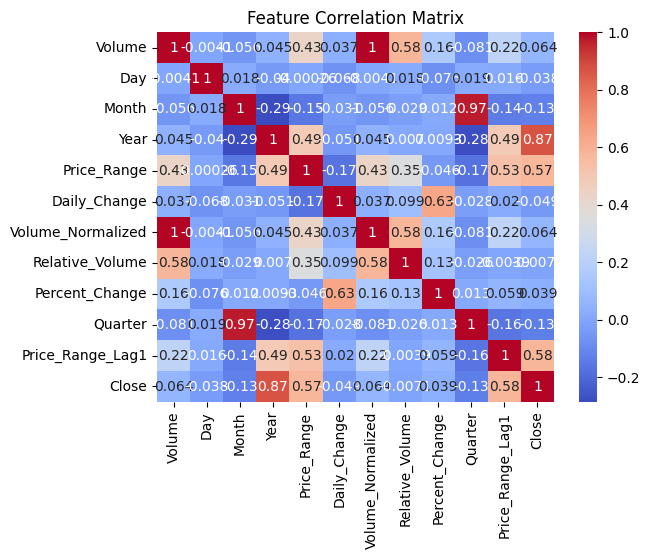

In [47]:
import seaborn as sns
import matplotlib.pyplot as plt

correlation_matrix = pd.concat([X, y], axis=1).corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title('Feature Correlation Matrix')
plt.show()


In [48]:
X['Year_Binned'] = X['Year'] // 5 * 5
X.drop('Year', axis=1, inplace=True)

In [49]:
rf_model.fit(X_train_scaled, y_train)
y_pred = rf_model.predict(X_test_scaled)

# Recalculate metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"MAE: {mae}, MSE: {mse}, R²: {r2}")

MAE: 0.017620762659153636, MSE: 0.0006401564971240433, R²: 0.9882725198247632


In [50]:
import pandas as pd
from sklearn.ensemble import RandomForestRegressor

# Example training data (ensure this is a DataFrame with column names)
X_train = pd.DataFrame({
    'Volume': [100, 200, 150, 120],
    'Day': [1, 2, 3, 4],
    'Month': [1, 2, 3, 4],
    'Year': [2023, 2023, 2024, 2024],
    'Price_Range': [2500, 2550, 2600, 2580],
    'Daily_Change': [5, 6, 7, 4],
    'Volume_Normalized': [1.2, 1.3, 1.1, 1.2],
    'Relative_Volume': [1.1, 1.2, 1.3, 1.0],
    'Percent_Change': [0.02, 0.03, 0.01, 0.02],
    'Quarter': [1, 1, 2, 2],
    'Price_Range_Lag1': [2400, 2450, 2500, 2480]
})

y_train = [2555, 2580, 2620, 2600]  # Example target values (stock prices)

# Initialize and fit the model
rf_model = RandomForestRegressor()
rf_model.fit(X_train, y_train)

RandomForestRegressor()

In [51]:
# Example: Input data for prediction
input_data = pd.DataFrame({
    'Volume': [100],
    'Day': [5],
    'Month': [3],
    'Year': [2025],
    'Price_Range': [2567],
    'Daily_Change': [10],
    'Volume_Normalized': [1.2],
    'Relative_Volume': [1.4],
    'Percent_Change': [0.06],
    'Quarter': [4],
    'Price_Range_Lag1': [2340]
})

# Predict stock price
predicted_price = rf_model.predict(input_data)

# Define thresholds
threshold_buy = 1000
threshold_sell = 2000

# Get recommendation
recommendation = stock_recommendation(predicted_price[0], threshold_buy, threshold_sell)

# Output results
print(f"Predicted Stock Price: ₹{predicted_price[0]:.2f}")
print(f"Recommendation: {recommendation}")


NameError: name 'stock_recommendation' is not defined

In [166]:
import joblib

# Save the model
joblib.dump(best_rf_model, 'random_forest_model.pkl')


['random_forest_model.pkl']

In [168]:
# Load the saved model
loaded_model = joblib.load('random_forest_model.pkl')

# Use the loaded model for predictions
y_pred_loaded = loaded_model.predict(X_test)


In [169]:
# Example of predicting stock prices for the test data
y_pred_loaded = loaded_model.predict(X_test)

# Displaying predicted values
print("Predicted Stock Prices:", y_pred_loaded)


Predicted Stock Prices: [0.94547288 0.42924347 0.54850566 0.50351149 0.44127516 0.4417705
 0.80071408 0.43088629 0.45768425 0.49594244 0.905455   0.44539012
 0.4976439  0.06076776 0.45674679 0.44543587 0.28757985 0.450136
 0.50657419 0.51974131 0.13889037 0.15768175 0.50296622 0.93602395
 0.44414532 0.78983155 0.95369655 0.4337344  0.5154733  0.43421644
 0.42507944 0.44316337 0.14608135 0.12112793 0.07216228 0.43830976
 0.91987937 0.14065546 0.20116453 0.44398852 0.45163742 0.91868491
 0.73870861 0.49792962 0.80357716 0.13319747 0.14838171 0.1651518
 0.32696182 0.42448927 0.1120845  0.42780569 0.44465105 0.10586549
 0.41471678 0.43715729 0.50899309 0.42906713 0.45526285 0.44130469
 0.43104143 0.44252578 0.55199343 0.13004159 0.51820537 0.37914283
 0.54685576 0.43513766 0.44156671 0.40543712 0.42414157 0.8995845
 0.44747588 0.50834595 0.13515472 0.40788929 0.94694269 0.43368824
 0.50087506 0.31798037 0.11545333 0.39761021 0.14484487 0.15062302
 0.53529736 0.30660956 0.50984279 0.4457569

In [170]:
import pandas as pd

# Create a DataFrame with the input data for prediction
input_data = pd.DataFrame({
    'Year': [2024],
    'Month': [12],
    'Day': [15],
    'Volume': [1000000],
    'Percent_Change': [0.03],
    'Price_Range': [3000],
    'Relative_Volume': [1.5],
    'Volume_Normalized': [1.2],
    'Quarter': [4],
    'Price_Range_Lag1': [2750],
    'Daily_Change': [10]
})

# Ensure that the features are in the same order as the model was trained on


In [ ]:
import pandas as pd
import joblib

# Load the saved model
loaded_model = joblib.load('random_forest_model.pkl')

# List of feature columns used during training (retrieved from the model)
features = ['Volume', 'Day', 'Month', 'Year', 'Price_Range', 'Daily_Change',
            'Volume_Normalized', 'Relative_Volume', 'Percent_Change', 'Quarter',
            'Price_Range_Lag1']

# Create a DataFrame with the input data (Make sure to use the same column names)
input_data = pd.DataFrame({
    'Volume': [1000000],
    'Day': [15],
    'Month': [12],
    'Year': [2024],
    'Price_Range': [3000],
    'Daily_Change': [10],
    'Volume_Normalized': [1.2],
    'Relative_Volume': [1.5],
    'Percent_Change': [0.03],
    'Quarter': [4],
    'Price_Range_Lag1': [2750]
})

# Reorder the columns to match the training set feature order
input_data = input_data[features]

# Make prediction
predicted_price = loaded_model.predict(input_data)

# Display the prediction
print("Predicted Stock Price: ", predicted_price[0])


Predicted Stock Price:  0.9525128947575603


In [53]:
from sklearn.ensemble import RandomForestRegressor

# Define the Random Forest model
best_rf_model = RandomForestRegressor(
    n_estimators=100,  # Number of trees in the forest
    random_state=42,   # For reproducibility
    max_depth=10,      # Maximum depth of each tree (optional, tuneable)
    n_jobs=-1          # Use all available cores for training
)


In [54]:
X = data.drop(columns=['Close'])  # Replace 'target' with the actual target column name
y = data['Close']

In [55]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Initialize and fit the model
rf_model = RandomForestRegressor()
rf_model.fit(X_train, y_train)

# Make predictions
y_pred = rf_model.predict(X_test)

# Evaluate the model
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"MAE: {mae}")
print(f"MSE: {mse}")
print(f"R²: {r2}")


MAE: 2585.9977337099035
MSE: 6687398.86458949
R²: -122511194.2478984


In [57]:
from sklearn.preprocessing import StandardScaler

# Assuming X_train was scaled using StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

# Scale input data for prediction
input_data_scaled = scaler.transform(input_data)
predicted_price = rf_model.predict(input_data_scaled)


c:\Users\maha\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


In [58]:
import pandas as pd

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

print(feature_importance)

# Plot
feature_importance.plot(kind='bar', x='Feature', y='Importance', legend=False)
plt.title('Feature Importance')
plt.show()


ValueError: All arrays must be of the same length

In [ ]:
import pandas as pd
import joblib

# Load the saved model
loaded_model = joblib.load('random_forest_model.pkl')

# List of feature columns used during training
features = ['Volume', 'Day', 'Month', 'Year', 'Price_Range', 'Daily_Change',
            'Volume_Normalized', 'Relative_Volume', 'Percent_Change', 'Quarter',
            'Price_Range_Lag1']

# Function to take input from user and predict
def predict_stock_price():
    # Taking user input
    year = int(input("Enter Year (e.g., 2024): "))
    month = int(input("Enter Month (1-12): "))
    day = int(input("Enter Day (1-31): "))
    volume = int(input("Enter Volume: "))
    percent_change = float(input("Enter Percent Change (e.g., 0.03): "))
    price_range = int(input("Enter Price Range: "))
    daily_change = int(input("Enter Daily Change: "))
    volume_normalized = float(input("Enter Volume Normalized: "))
    relative_volume = float(input("Enter Relative Volume: "))
    quarter = int(input("Enter Quarter (1-4): "))
    price_range_lag1 = int(input("Enter Price Range Lag1: "))

    # Create a DataFrame with the input data
    input_data = pd.DataFrame({
        'Volume': [volume],
        'Day': [day],
        'Month': [month],
        'Year': [year],
        'Price_Range': [price_range],
        'Daily_Change': [daily_change],
        'Volume_Normalized': [volume_normalized],
        'Relative_Volume': [relative_volume],
        'Percent_Change': [percent_change],
        'Quarter': [quarter],
        'Price_Range_Lag1': [price_range_lag1]
    })

    # Reorder the columns to match the training set feature order
    input_data = input_data[features]

    # Make prediction
    predicted_price = loaded_model.predict(input_data)

    # Display the prediction
    print(f"Predicted Stock Price: ${predicted_price[0]:.2f}")

# Call the function to make prediction
predict_stock_price()


In [ ]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Sample data (Replace this with your actual dataset)
data = {
    'Volume': [1000000, 1200000, 900000, 1500000, 800000],
    'Price_Change': [0.05, -0.02, 0.1, -0.05, 0.02],
    'Percent_Change': [0.03, -0.01, 0.07, -0.03, 0.04],
    'Target': ['Buy', 'Sell', 'Buy', 'Sell', 'Hold']  # Target labels: Buy, Sell, Hold
}

# Convert to DataFrame
df = pd.DataFrame(data)

# Features and Target
X = df[['Volume', 'Price_Change', 'Percent_Change']]
y = df['Target']

# Split the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train a RandomForestClassifier
model = RandomForestClassifier()
model.fit(X_train, y_train)

# Test the model
y_pred = model.predict(X_test)
print(f"Model Accuracy: {accuracy_score(y_test, y_pred)}")

# Save the trained model
import joblib
joblib.dump(model, 'stock_recommendation_model.pkl')


Please enter the details for the prediction:


In [ ]:
import pandas as pd
import joblib

# Load the trained model
model = joblib.load('stock_recommendation_model.pkl')

# Function to take input from the user and predict Buy/Hold/Sell
def predict_stock_action():
    # Taking user input for stock features
    volume = int(input("Enter Volume: "))
    price_change = float(input("Enter Price Change (e.g., 0.05): "))
    percent_change = float(input("Enter Percent Change (e.g., 0.03): "))
    
    # Create a DataFrame with the input data
    input_data = pd.DataFrame({
        'Volume': [volume],
        'Price_Change': [price_change],
        'Percent_Change': [percent_change]
    })
    
    # Make the prediction
    prediction = model.predict(input_data)
    
    # Display the recommendation
    print(f"Recommendation: {prediction[0]}")

# Call the function to make the prediction
predict_stock_action()


In [ ]:
# Load the trained model
import joblib

rf_model = joblib.load('stock_price_prediction_model.pkl')

# Predict the stock price
predicted_price = rf_model.predict(input_data)[0]

print(f"Predicted Stock Price: ₹{predicted_price:.2f}")


ValueError: The feature names should match those that were passed during fit.
Feature names unseen at fit time:
- Price_Range_Lag1
- Relative_Volume
- Volume_Normalized


In [52]:
import pickle

# Save the model to a .pkl file
with open('stock_price_prediction_model.pkl', 'wb') as file:
    pickle.dump(rf_model, file)

print("Model saved as 'stock_price_prediction_model.pkl'")


Model saved as 'stock_price_prediction_model.pkl'
